# DART observation-diagnostic experiment comparison

## Purpose

Compare time-series diagnostics from existing E3SM-DART `obs_diag` products across configured experiments. The notebook finds observation types for each requested variable, extracts diagnostic metrics, combines compatible types, caches processed results, and plots experiment comparisons.

## Inputs

Experiment names, archive keys, aliases, and periods are defined in `USER_EXPERIMENTS`. Source diagnostic files must already exist under `DART_DATA_ROOT`; this notebook does not generate them. Processed request caches are reused when their configuration and source-file fingerprints match. Set `FORCE_COMPUTE=True` to rebuild them.

## Comparison modes

- **`obs_space` / `obs_space_s0`**: S0 December experiments using `diag2`.
- **`obs_space_s1`**: S1 May experiments using `diag2`.
- **`common_s0`**: S0 December experiments using common-observation diagnostics (`diag5`).
- **`common_s1`**: S1 May experiments using common-observation diagnostics (`diag5`).

Obs-space modes default to the global region (`REGION = "GB"`) and process every pressure bin available in the diagnostic files. Each mode saves a multi-page all-layer PDF and a separate PDF for the selected 450–600 hPa layer. Pages use a 3-by-2 layout: wind first, temperature second, with RMSE, spread/RMSE, and rejection rate in rows. `obs_space` remains an alias for S0.

The common-observation modes support zonal wind (U), meridional wind (V), temperature (T), and specific humidity (Q). `common_s0` defaults to the focused U/temperature comparison at 450–600 hPa.

## Processing

For each selected variable, the workflow finds matching non-satellite pressure-level observation types, extracts diagnostics for the configured experiments, and checks that pressure levels and time coordinates are consistent. RMSE and total spread are equal-weight averages across matched observation types. Rejection rate is computed from pooled `Nused` and `Nposs` counts.

Available metrics include bias, RMSE, total spread, spread/RMSE, and observation rejection rate. `METRICS_TO_PLOT` selects metrics for the general modes; focused summaries use their configured metric lists.

## Outputs

Figures are saved as PDF files beneath `DIAG_FIGURE_DIR / analysis_atm_da / obs_diagnostics / time_series`. Processed NetCDF caches are stored beneath the corresponding `WORKFLOW_DATA_DIR` directory. Review the user setup before running the notebook from top to bottom.

## 1. Libraries

Load the standard scientific, plotting, and utility libraries used below.


In [118]:
# =============================================================================
# LIBRARIES
# =============================================================================
from pathlib import Path
import json
import os
import sys
import warnings
import logging
from collections import defaultdict
from typing import Tuple, List, Dict, Optional

# === Numerical and Data Tools ===
import numpy as np
import numpy.ma as ma
import pandas as pd
import xarray as xr
import xcdat as xc
import xskillscore as xs

from datetime import datetime

# === Plotting ===
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
from matplotlib.patches import Polygon
from matplotlib import ticker
from matplotlib.ticker import FuncFormatter

# === Mapping and Projections ===
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker


## 2. User setup

Edit this cell for normal plotting changes. It contains paths, diagnostic layouts, experiments, modes, variables, regions, time limits, Dask options, and figure settings.


In [ ]:
# =============================================================================
# USER SETUP
# Edit this cell to select data, experiments, diagnostics, and plot appearance.
# =============================================================================
INPUT_DATA_ROOT = Path("/compyfs/zhan391/v3_dart_cda_scratch")
WORK_DIR = Path("/compyfs/zhan391/work_package/e3sm_dart_analysis")
DIAGNOSTIC_OUTPUT_ROOT = Path("/compyfs/www/zhan391/e3sm_dart/diag_dart_2026")
WORKFLOW_NAME = "analysis_atm_da"

DIAGNOSTIC_DIR = WORK_DIR / "diagnostic"
if not DIAGNOSTIC_DIR.is_dir():
    raise FileNotFoundError(f"Diagnostic work directory not found: {DIAGNOSTIC_DIR}")
if str(DIAGNOSTIC_DIR) not in sys.path:
    sys.path.insert(0, str(DIAGNOSTIC_DIR))

from configs.output_paths import workflow_output_dirs
WORKFLOW_DATA_DIR, WORKFLOW_FIGURE_DIR = workflow_output_dirs(
    WORKFLOW_NAME,
    output_root=DIAGNOSTIC_OUTPUT_ROOT,
)

PROJECT_ROOT = WORK_DIR
DIAGNOSTIC_DIR = PROJECT_ROOT / "diagnostic"
if not (DIAGNOSTIC_DIR / "configs").is_dir() or not (DIAGNOSTIC_DIR / "util").is_dir():
    raise FileNotFoundError(
        f"Invalid E3SM-DART analysis root: {PROJECT_ROOT}. "
        "Set WORK_DIR in the top-level parameter cell to the repository root."
    )

DART_DATA_ROOT = INPUT_DATA_ROOT
if str(DIAGNOSTIC_DIR) not in sys.path:
    sys.path.insert(0, str(DIAGNOSTIC_DIR))

DIAG_DATA_DIR = DIAGNOSTIC_OUTPUT_ROOT / "data"
DIAG_FIGURE_DIR = DIAGNOSTIC_OUTPUT_ROOT / "figure"

DIAG_PATH_TEMPLATES = {
    "cam": str(
        DART_DATA_ROOT / "%(RUNNAME)" / "%(CASENAME)" / "cam" / "dart_diagnostics" / "%(DIAG)"
    ),
    "e3sm": str(
        DART_DATA_ROOT / "%(RUNNAME)" / "%(CASENAME)" / "eam" / "dart_diagnostics" / "%(DIAG)"
    ),
}
CAM_LAYOUT_EXPERIMENTS = {"CAM80-S0", "CAM80-S1"}

USER_EXPERIMENTS = {
    "CAM80-S0": {
        "run": "f.e21.FHIST_BGC.f09_025.CAM6assim.011",
        "key": "dart_en80",
        "alias": "CAM6EN80",
        "period": "2011120100-2012010100",
    },
    "CAM80-S1": {
        "run": "f.e22.FHIST_BGC.f09_025.CAM6assim.011",
        "key": "dart_en80",
        "alias": "CAM6EN80S1",
        "period": "2012050100-2012060100",
    },
    "CTRL10-S0": {
        "run": "CTRLEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en10",
        "alias": "CTRLEN10",
        "period": "2011120100-2012010100",
    },
    "DART10-S0": {
        "run": "DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en10",
        "alias": "DARTEN10",
        "period": "2011120100-2012010100",
    },
    "DART20-S0": {
        "run": "DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en20",
        "alias": "DARTEN20",
        "period": "2011120100-2012010100",
    },
    "DART40INF0p6-S0": {
        "run": "DARTEN40_INF0p6_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en40",
        "alias": "DARTEN40",
        "period": "2011120100-2012010100",
    },
    "DART40-S0": {
        "run": "DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en40",
        "alias": "DARTEN40",
        "period": "2011120100-2012010100",
    },
    "DART40-S1": {
        "run": "DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "key": "dart_en40",
        "alias": "DARTEN40S1",
        "period": "2012050100-2012060100",
    },
}
USER_DIAG_SETS = ("obs_seq", "obs_diag", "obs_common", "closest_member", "cam6_common")
USER_EXPERIMENT_OVERRIDES = {}
for experiment_name, experiment in USER_EXPERIMENTS.items():
    layout = "cam" if experiment_name in CAM_LAYOUT_EXPERIMENTS else "e3sm"
    experiment["path_template"] = DIAG_PATH_TEMPLATES[layout]

#`obs_space` / `obs_space_s0`: S0 December experiments using `diag2`.
#`obs_space_s1`: S1 May experiments using `diag2`.
#`common_s0`: S0 December experiments using common-observation diagnostics (`diag5`).
#`common_s1`: S1 May experiments using common-observation diagnostics (`diag5`).
PLOT_MODE = "obs_space"
REGION = "GB"
SHOW = True
SAVE = True
PANEL_WIDTH = 18
PANEL_HEIGHT = 12
FONT_SIZE = 24
DPI = 300
XMIN = 0
XMAX = 31
FOCUSED_COMMON_S0 = True

# Scale typography in the obs-space panels relative to FONT_SIZE.
OBS_SPACE_FONT_SCALES = {
    "panel_title": 0.95,
    "axis_label": 0.90,
    "tick_label": 0.85,
    "legend": 0.85,
}

REGION_NAMES = {
    "GB": "Global",
    "NH": "Northern Hemisphere",
    "SH": "Southern Hemisphere",
    "TP": "Tropics",
    "NA": "North America",
}

METRICS_TO_PLOT = ["rmse", "spread", "rejection"]
METRIC_CATALOG = {
    "bias": {"name": "Mean Error (Bias)", "unit": None, "symmetric": True},
    "rmse": {"name": "Root Mean Square Error (RMSE)", "unit": None},
    "raw_spread": {"name": "Total Ensemble Spread", "unit": None},
    "spread": {"name": "Ratio of Spread to RMSE", "unit": "unitless"},
    "rejection": {"name": "Observation rejection rate", "unit": "%"},
}

S0_EXPERIMENTS = ["CAM80-S0", "DART10-S0", "DART20-S0", "DART40-S0"]
S1_EXPERIMENTS = ["CAM80-S1", "DART40-S1"]

COMMON_VARIABLES = {
    "U_WIND": {
        "lev": "plev", "dtype": "guess", "name": "U",
        "unit": "m $s^{-1}$", "plot_levs": ["450-600 hPa", "225-275 hPa"],
    },
    "V_WIND": {
        "lev": "plev", "dtype": "guess", "name": "V",
        "unit": "m $s^{-1}$", "plot_levs": ["450-600 hPa", "225-275 hPa"],
    },
    "Temperature": {
        "lev": "plev", "dtype": "guess", "name": "T",
        "unit": "$^\\circ$C", "plot_levs": ["450-600 hPa", "225-275 hPa"],
    },
    "Humidity": {
        "lev": "plev", "dtype": "guess", "name": "Q",
        "unit": "g kg$^{-1}$", "plot_levs": ["450-600 hPa", "225-275 hPa"],
    },
}

MODE_CONFIGS = {
    "obs_space": {
        "diag_set": "diag2", "tunit": "2011-12-01",
        "experiments": S0_EXPERIMENTS,
        "variables": {
            "Temperature": {
                "lev": "plevel", "dtype": "guess", "name": "Temperature",
                "unit": "$^\\circ$ C", "plot_levs": ["450-600 hPa", "225-275 hPa"],
                "y1axis": [1, 7], "y2axis": [0, 18],
            },
        },
    },
    "common_s0": {
        "diag_set": "diag5", "tunit": "2011-12-01",
        "experiments": S0_EXPERIMENTS, "variables": COMMON_VARIABLES,
    },
    "common_s1": {
        "diag_set": "diag5", "tunit": "2012-05-01",
        "experiments": S1_EXPERIMENTS, "variables": COMMON_VARIABLES,
    },
}

USE_DASK = True
DASK_CHUNKS = {"time": 31, "copy": -1, "plevel": -1, "region": 1}
PERSIST_MEANS = False
FORCE_COMPUTE = False

COMMON_S0_FIGURE = {
    "variables": ("U_WIND", "Temperature"),
    "level": "450-600 hPa",
    "metrics": ("rmse", "spread", "rejection"),
    "xmin": XMIN, "xmax": XMAX,
    "xunit": MODE_CONFIGS["common_s0"]["tunit"],
    "show": SHOW, "save": SAVE,
    "panel_width": PANEL_WIDTH, "panel_height": PANEL_HEIGHT,
    "font_size": FONT_SIZE, "dpi": DPI, "formats": ("pdf"),
}


In [120]:
COMMON_S0_FIGURE["formats"] = ("pdf",)

OBS_SPACE_VARIABLES = {
    "U_WIND": {
        "lev": "plevel",
        "dtype": "guess",
        "name": "U",
        "unit": "m $s^{-1}$",
        "plot_levs": ["450-600 hPa"],
    },
    "Temperature": {
        **MODE_CONFIGS["obs_space"]["variables"]["Temperature"],
        "name": "T",
        "plot_levs": ["450-600 hPa"],
    },
}
MODE_CONFIGS["obs_space"]["variables"] = OBS_SPACE_VARIABLES

# Keep the historical obs_space mode as the S0 alias.
MODE_CONFIGS["obs_space_s0"] = {
    **MODE_CONFIGS["obs_space"],
    "experiments": S0_EXPERIMENTS,
}
MODE_CONFIGS["obs_space_s1"] = {
    **MODE_CONFIGS["obs_space"],
    "tunit": "2012-05-01",
    "experiments": S1_EXPERIMENTS,
}
OBS_SPACE_FIGURE = {
    "variables": ("U_WIND", "Temperature"),
    "level": "450-600 hPa",
    "width": 16,
}

### Observation-space mode selection

Set `PLOT_MODE = "obs_space"` or `"obs_space_s0"` for S0 December, or `"obs_space_s1"` for S1 May. `REGION = "GB"` selects the global domain. The workflow saves a multi-page all-layer PDF and a separate PDF for the selected 450–600 hPa layer. Wind is the first column, temperature the second; RMSE, spread/RMSE, and rejection rate are the rows.

Adjust `OBS_SPACE_FONT_SCALES` to tune panel titles, axis labels, tick labels, and the legend as multiples of `FONT_SIZE`.

## 3. Project setup

Load project-local helpers and translate the user experiment definitions into the reader configuration.


In [121]:
if str(DIAGNOSTIC_DIR) not in sys.path:
    sys.path.insert(0, str(DIAGNOSTIC_DIR))

from util.dart_observation_diagnostics import (
    DartObsDiagReader
)

# === Suppress warnings globally ===
warnings.filterwarnings("ignore")

from util.dask_helpers import configure_dask, open_dataset_lazy, persist_if_dask

from configs.analysis_da_experiment_config import extract_obs_diag_config

def extract_exp_info(exp_name: str = None) -> dict:
    return extract_obs_diag_config(
        exp_name=exp_name,
        experiments=USER_EXPERIMENTS,
        data_path=DART_DATA_ROOT,
        diag_sets=USER_DIAG_SETS,
        experiment_overrides=USER_EXPERIMENT_OVERRIDES,
    )

## 4. Shared processing and plotting utilities

Define the shared class used to combine observation types and construct diagnostic time-series panels. This implementation normally does not need editing.


In [122]:
class ObsDiagPlotter:
    def __init__(
        self, var, var_dict, data_dict, fig_path,
        plevstr, regnam=None
    ):
        self.var = var
        self.var_dict = var_dict or {}
        self.data_dict = data_dict or {}
        self.fig_path = fig_path
        self.plevstr = plevstr or []
        self.regnam = regnam
        self._prepare_common()

    def _prepare_common(self):
        self.cmap = {
            'blue': '#377eb8', 'orange': '#ff7f00', 'green': '#4daf4a',
            'pink': '#f781bf', 'brown': '#a65628', 'purple': '#984ea3',
            'gray': '#999999', 'red': '#e41a1c', 'yellow': '#dede00'
        }

    def _set_axes_limits(self, ax, xlim=None, ylim=None, yticks=None, xticks=None):
        if xlim is not None: ax.set_xlim(*xlim)
        if ylim is not None: ax.set_ylim(*ylim)
        if yticks is not None: ax.set_yticks(yticks)
        if xticks is not None: ax.set_xticks(xticks)

    # NEW: robust getter for inner var-config
    def _varcfg(self):
        """Return inner var-config whether var_dict is an inner dict or a single-entry wrapper."""
        vd = self.var_dict
        if isinstance(vd, dict) and 'y1aix' in vd:
            return vd
        if isinstance(vd, dict) and len(vd) == 1:
            return next(iter(vd.values()))
        raise ValueError(
            "var_dict not recognized. Pass inner dict with keys like 'y1aix'/'y2aix', "
            "or a single-entry wrapper {var_key: inner}."
        )

    def check_flat_lev_consistency(self, lev_dict):
        ref_var = next(iter(lev_dict))
        reference = lev_dict[ref_var]
        for var, lev in lev_dict.items():
            if lev != reference:
                raise ValueError(
                    f"Inconsistent pressure level list for variable '{var}'.\n"
                    f"Expected: {reference}\nFound:    {lev}"
                )
        print("All level lists are consistent across variables.")
        return reference
    
    def build_ts_var_dict(
        self, var_key: str = None, name: str = None,
        y1axis: list = None, y2axis: list = None
    ) -> dict:
        var_key = var_key or 'RADIOSONDE_U'
        name = name or 'RADIOSONDE_U_WIND_COMPONENT'
        entry = {
            'name': name,
            'lev_type': 'pressure',
            'CopySpread': 'totalspread',
            'CopyRMSE': 'rmse',
            'CopyBias': 'bias',
            'CopyNposs': 'Nposs',
            'CopyNused': 'Nused',
            'type1': 'guess',
            'type2': 'VPguess',
            'type3': 'guess_RankHist',
            'y1aix': y1axis if y1axis is not None else [0, 10],
            'y2aix': [0, 100],
            'y1aix0': y2axis if y2axis is not None else [0, 10],
            'y2aix0': [0, 100],
        }
        return {var_key: entry}
    
    def _sum_observation_counts(self, data_dict, experiment, key):
        values = [
            entry[experiment][key]
            for entry in data_dict.values()
            if experiment in entry
            and key in entry[experiment]
            and getattr(entry[experiment][key], "size", 0) > 0
        ]
        if not values:
            return None
        arrays = [
            value if isinstance(value, xr.DataArray) else xr.DataArray(value)
            for value in values
        ]
        return xr.concat(arrays, dim="obs_type").sum(
            dim="obs_type", skipna=True, min_count=1
        )

    def compute_experiment_means(self, data_dict, diagnostic_keys_to_average, persist=False):
        """Average RMSE/spread by observation type and pool rejection counts."""
        if not data_dict:
            raise ValueError("data_dict is empty; cannot compute means.")

        experiments = list(next(iter(data_dict.values())))
        all_keys = {
            key
            for variable_data in data_dict.values()
            for experiment_data in variable_data.values()
            for key in experiment_data
        }
        mean_dict = {experiment: {} for experiment in experiments}

        for experiment in experiments:
            for key in all_keys:
                if key == "rejection" and key in diagnostic_keys_to_average:
                    npos = self._sum_observation_counts(data_dict, experiment, "npos")
                    nused = self._sum_observation_counts(data_dict, experiment, "nused")
                    value = (
                        xr.where(npos > 0, 100.0 * (1.0 - nused / npos), np.nan)
                        if npos is not None and nused is not None
                        else None
                    )
                    mean_dict[experiment][key] = (
                        persist_if_dask(value, persist) if value is not None else None
                    )
                elif key in diagnostic_keys_to_average:
                    values = [
                        entry[experiment][key]
                        for entry in data_dict.values()
                        if experiment in entry
                        and key in entry[experiment]
                        and getattr(entry[experiment][key], "size", 0) > 0
                    ]
                    if not values:
                        mean_dict[experiment][key] = None
                        continue
                    arrays = [
                        value if isinstance(value, xr.DataArray) else xr.DataArray(value)
                        for value in values
                    ]
                    value = xr.concat(arrays, dim="obs_type").mean(
                        dim="obs_type", skipna=True
                    )
                    mean_dict[experiment][key] = persist_if_dask(value, persist)
                else:
                    values = [
                        entry[experiment][key]
                        for entry in data_dict.values()
                        if experiment in entry and key in entry[experiment]
                    ]
                    mean_dict[experiment][key] = values[0] if values else None

            for key in ("time", "time_unit", "period", "lev", "levp"):
                values = [
                    entry[experiment][key]
                    for entry in data_dict.values()
                    if experiment in entry and key in entry[experiment]
                ]
                if values and any(
                    not np.array_equal(np.asarray(values[0]), np.asarray(value))
                    for value in values[1:]
                ):
                    raise ValueError(
                        f"Inconsistent {key!r} across observation types for {experiment}."
                    )

        return mean_dict

    def _auto_ylims(self, values, *, pad_frac=0.25, symmetric=False):
        """
        Compute nice y-limits from a 1D array-like metric.

        Parameters
        ----------
        values : array-like
            Metric values (nan-safe).
        pad_frac : float
            Fractional padding on each side (default 0.10 = 10%).
        symmetric : bool
            If True, make y-limits symmetric around zero.
        """
        import numpy as np

        arr = np.asarray(values, dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            return (-1, 1)  # fallback

        vmin, vmax = arr.min(), arr.max()

        # If all values identical → pad around that value
        if np.isclose(vmin, vmax):
            delta = abs(vmin) * pad_frac if vmin != 0 else 1.0
            return (vmin - delta, vmax + delta)

        if symmetric:
            bound = max(abs(vmin), abs(vmax))
            pad = bound * pad_frac
            return (-bound - pad, bound + pad)

        # Regular: padded min/max
        pad = (vmax - vmin) * pad_frac
        return (vmin - pad, vmax + pad)


    def _select_time_series_at_level(self, values, time, mask, level_idx):
        """Return values/time for one level, accepting time-level or level-time arrays."""
        values = np.asarray(values)
        time = np.asarray(time)
        mask = np.asarray(mask, dtype=bool)
        ntime = time.size
        nlev = len(self.plevstr)

        if values.ndim == 2:
            if values.shape[0] == ntime:
                if level_idx >= values.shape[1]:
                    return None, None
                return values[mask, level_idx], time[mask]
            if values.shape[1] == ntime:
                if level_idx >= values.shape[0]:
                    return None, None
                return values[level_idx, mask], time[mask]
            raise ValueError(
                f"Cannot align metric array shape {values.shape} with time length {ntime}. "
                "Expected (time, level) or (level, time)."
            )

        if values.ndim == 1:
            if values.size == ntime:
                return values[mask], time[mask]
            if values.size == nlev:
                # A level-only profile has already lost the time dimension.
                return None, None
            raise ValueError(
                f"Cannot align 1-D metric array length {values.size} with time length {ntime} "
                f"or level length {nlev}."
            )

        raise ValueError(f"Unsupported metric array with {values.ndim} dimensions.")

    def plot_timeseries(
            self, 
            plev, 
            xmin=None, 
            xmax=None, 
            xunit=None,
            fig_idx = 0,
            show=False, 
            save=True,
            panel_width=14, 
            panel_height=5,
            fontz=12, 
            dpi=None,
            metric_dict=None,
        ):
        """
        Plot stacked time-series panels for the chosen metrics at one pressure level,
        overlaying all experiments in each panel.

        Args:
            plev: pressure level string present in self.plevstr
            xmin, xmax: time bounds (same units as data's 'time')
            xunit: optional label suffix like 'Days since 2011-12-01'
            metric_dict: dict of metrics to plot, e.g.
                {
                  "rmse":     {"name": "RMSE",     "unit": "m/s", "pad_frac": 0.05},
                  "spread":   {"name": "Spread",   "unit": "m/s", "pad_frac": 0.25},
                  "rejection":{"name": "Rejection","unit": "%",   "ylim": (0, 100)},
                }
        """
        if not self.data_dict:
            raise ValueError("data_dict is empty; nothing to plot.")
        if not self.plevstr:
            raise ValueError("plevstr is empty; cannot index pressure levels.")
        try:
            dk = self.plevstr.index(plev)
        except ValueError:
            raise ValueError(f"Level '{plev}' not found in plevstr list.")

        # --- metrics & config ---
        if metric_dict is None:
            raise ValueError("metric_dict must be provided.")
        metrics = list(metric_dict.keys())
        allowed = {"rmse", "spread", "rejection"}
        bad = [m for m in metrics if m not in allowed]
        if bad:
            raise ValueError(f"Unsupported metrics {bad}; allowed are {sorted(allowed)}")

        # global time bounds if not given
        all_mins, all_maxs = [], []
        for d in self.data_dict.values():
            t = np.asarray(d["time"], dtype=float)
            if t.size == 0:
                continue
            tmin = np.nanmin(t)
            tmax = np.nanmax(t)
            if np.isfinite(tmin):
                all_mins.append(tmin)
            if np.isfinite(tmax):
                all_maxs.append(tmax)
        if not all_mins or not all_maxs:
            raise ValueError("No valid time data in data_dict.")
        if xmin is None:
            xmin = min(all_mins)
        if xmax is None:
            xmax = max(all_maxs)

        # style map per experiment (consistent across panels)
        exp_names = list(self.data_dict.keys())
        color_list = plt.cm.tab10.colors
        marker_list = ["o", "s", "^", "v", "*", "D", "P", "X"]
        linestyle_list = ["-", "--", "-.", ":"]
        style_map = {
            exp: {
                "color":      color_list[i % len(color_list)],
                "marker":     marker_list[i % len(marker_list)],
                "linestyle":  linestyle_list[i % len(linestyle_list)],
                "linewidth":  1.8,
                "markersize": 5 + (i % 3) * 1.5,
            }
            for i, exp in enumerate(exp_names)
        }

        # ------------------------------------------------------
        # 1) FIRST PASS: collect all values per metric (masked in time)
        # ------------------------------------------------------
        collected = {m: [] for m in metrics}

        for metric in metrics:
            for exp, d in self.data_dict.items():
                time = np.asarray(d["time"])
                mask = (time >= xmin) & (time <= xmax)

                if metric == "spread":
                    spread = np.asarray(d["spread"], dtype=float)
                    rmse = np.asarray(d["rmse"], dtype=float)
                    values = np.divide(
                        spread, rmse,
                        out=np.full_like(spread, np.nan, dtype=float),
                        where=np.isfinite(rmse) & (rmse != 0),
                    )
                elif metric == "raw_spread":
                    values = np.asarray(d["spread"], dtype=float)
                elif metric == "bias":
                    values = np.asarray(d["bias"], dtype=float)
                elif metric == "rejection":
                    values = np.asarray(d["rejection"], dtype=float)
                else:
                    values = np.asarray(d["rmse"], dtype=float)

                if values.size == 0 or not np.isfinite(values).any():
                    continue
                vals, _ = self._select_time_series_at_level(values, time, mask, dk)
                if vals is None:
                    continue

                if vals.size > 0:
                    collected[metric].append(vals)

        # compute y-limits for each metric
        ylims = {}
        for metric in metrics:
            cfg = metric_dict[metric]
            # explicit ylim from metric_dict wins
            if "ylim" in cfg and cfg["ylim"] is not None:
                ylims[metric] = tuple(cfg["ylim"])
                continue

            all_vals = np.concatenate([np.ravel(v) for v in collected[metric]]) if collected[metric] else np.array([])
            pad = cfg.get("pad_frac", 0.1)
            sym = cfg.get("symmetric", False)
            ylims[metric] = self._auto_ylims(all_vals, pad_frac=pad, symmetric=sym)

        # ------------------------------------------------------
        # 2) SECOND PASS: actually plot using the decided y-limits
        # ------------------------------------------------------
        nrows = len(metrics)
        ncols = 1
        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(panel_width, panel_height),
            sharey=False,
        )

        axes = np.atleast_1d(axes)

        for i, metric in enumerate(metrics):
            ax = axes[i]

            for exp, d in self.data_dict.items():
                time = np.asarray(d["time"])
                mask = (time >= xmin) & (time <= xmax)

                if metric == "spread":
                    spread = np.asarray(d["spread"], dtype=float)
                    rmse = np.asarray(d["rmse"], dtype=float)
                    values = np.divide(
                        spread, rmse,
                        out=np.full_like(spread, np.nan, dtype=float),
                        where=np.isfinite(rmse) & (rmse != 0),
                    )
                elif metric == "raw_spread":
                    values = np.asarray(d["spread"], dtype=float)
                elif metric == "bias":
                    values = np.asarray(d["bias"], dtype=float)
                elif metric == "rejection":
                    values = np.asarray(d["rejection"], dtype=float)
                else:
                    values = np.asarray(d["rmse"], dtype=float)

                if values.size == 0 or not np.isfinite(values).any():
                    continue
                vals, time_f = self._select_time_series_at_level(values, time, mask, dk)
                if vals is None:
                    continue

                style  = style_map[exp]

                ax.plot(
                    time_f,
                    vals,
                    label=exp,
                    color=style["color"],
                    marker=style["marker"],
                    linestyle=style["linestyle"],
                    linewidth=style["linewidth"],
                    markersize=style["markersize"],
                )

            # axes, labels
            self._set_axes_limits(ax, xlim=(xmin, xmax), ylim=ylims[metric])
            ax.tick_params(labelsize=fontz)

            panel_title = f"({chr(97 + i + fig_idx)}) {metric_dict[metric]['name']}"
            ax.set_title(panel_title, fontsize=fontz * 1.05, pad=8, loc="left")
            ax.set_title(f"{self.var} ({plev})", fontsize=fontz * 1.05, pad=8, loc="right")

            if xunit:
                ax.set_xlabel(f"Days since {xunit}", fontsize=fontz* 1.0)

            ax.set_ylabel(metric_dict[metric]["unit"], fontsize=fontz * 1.0)

            # optional nice ticks for rejection (%)
            if metric == "rejection" and ylims[metric] == (0, 100):
                ax.set_yticks(np.arange(0, 101, 20))

            # Legend only on the first panel
            if i == len(metrics)-1:
                ax.legend(
                    loc="upper right",
                    fontsize=fontz * 0.95,
                    frameon=True,
                    handlelength=2.2,
                    labelspacing=0.5,
                )

        plt.tight_layout()
        if show:
            plt.show()
        if save:
            os.makedirs(self.fig_path, exist_ok=True)
            reg_str = (self.regnam or "region").replace(" ", "_")
            safe_var = (self.var or "var").replace(" ", "_")
            mtag = "_".join(metrics)
            fname = os.path.join(
                self.fig_path,
                f"fig_obs_diag_ts_{mtag}_{safe_var}_{reg_str}_{str(plev).replace(' ', '')}.pdf",
            )
            fig.savefig(fname, dpi=dpi, bbox_inches="tight")
            plt.close(fig)

## 5. Cache and workflow utilities

Define fixed request-cache paths, validate cached metadata, read and process missing diagnostics, and keep plotting separate from data preparation.


In [123]:
def _make_metric_dict(unit, metrics=None):
    metrics = METRICS_TO_PLOT if metrics is None else metrics
    unknown = set(metrics) - set(METRIC_CATALOG)
    if unknown:
        raise ValueError(f"Unknown metrics {sorted(unknown)}; available: {sorted(METRIC_CATALOG)}")
    metric_dict = {key: dict(METRIC_CATALOG[key]) for key in metrics}
    for key in ("bias", "rmse", "raw_spread"):
        if key in metric_dict:
            metric_dict[key]["unit"] = unit
    return metric_dict

def _diagnostic_keys_for_metrics(metrics):
    dependencies = {"bias": {"bias"}, "rmse": {"rmse"}, "raw_spread": {"spread"}, "spread": {"spread", "rmse"}, "rejection": {"rejection"}}
    return sorted(set().union(*(dependencies[metric] for metric in metrics)))

def _find_obs_matches(reader, varstr, varlev):
    all_obs = reader.extract_obs_group()
    matches = [
        (group, lev, vv)
        for group, levels in all_obs.items()
        if "Satellite" not in group
        for lev, variables in levels.items()
        if varlev.lower() in lev.lower()
        for vv in variables
        if varstr.lower() in vv.lower()
    ]
    if not matches:
        raise RuntimeError(
            f"No matches for var='{varstr}' at level like '{varlev}' "
            "(excluding Satellite). Check your obs groups."
        )
    return matches



def _validate_input_files(reader, exp_dict, diag_set):
    missing = []
    for experiment_name, experiment in exp_dict.items():
        directory, filename = reader.resolve_dart_file_path(
            experiment,
            experiment_name,
            diag_set,
            experiment["period"],
        )
        file_path = Path(directory) / filename
        if not file_path.is_file():
            missing.append(file_path)

    if missing:
        formatted = "\n".join(f"  - {file_path}" for file_path in missing)
        raise FileNotFoundError(
            "Missing DART diagnostic input files. Check DART_DATA_ROOT, "
            "DIAG_PATH_TEMPLATES, experiment keys, and periods:\n" + formatted
        )


CACHE_SCHEMA_VERSION = 2


def _cache_token(value):
    return "".join(char if char.isalnum() else "-" for char in str(value)).strip("-")


def _cache_metadata(request_metadata):
    """Add configuration and available source-file fingerprints to a request."""
    metadata = dict(request_metadata)
    metadata["data_root"] = str(DART_DATA_ROOT.resolve())
    metadata["experiment_specs"] = {
        name: USER_EXPERIMENTS[name] for name in request_metadata["experiments"]
    }
    mode = request_metadata["mode"]
    variable = request_metadata["variable"]
    metadata["variable_config"] = MODE_CONFIGS[mode]["variables"][variable]

    experiment_info = extract_exp_info()["experiments"]
    reader = DartObsDiagReader(extract_exp_info()["global"])
    fingerprints = []
    for name in request_metadata["experiments"]:
        experiment = experiment_info[name]
        directory, filename = reader.resolve_dart_file_path(
            experiment, name, request_metadata["diag_set"], experiment["period"]
        )
        source_path = Path(directory) / filename
        try:
            stat = source_path.stat()
        except FileNotFoundError:
            fingerprints = None
            break
        fingerprints.append({
            "path": str(source_path),
            "size": stat.st_size,
            "mtime_ns": stat.st_mtime_ns,
        })
    metadata["source_fingerprints"] = fingerprints
    return metadata


def _processed_cache_path(cache_dir, mode, region, variable):
    """Return the single fixed cache target for one mode/region/variable."""
    filename = (
        f"obs_diag_{_cache_token(mode)}_{_cache_token(region)}_"
        f"{_cache_token(variable)}.nc"
    )
    return Path(cache_dir) / filename


def _as_time_level(values, ntime, nlevels, label):
    array = np.asarray(values, dtype=float)
    if array.shape == (ntime, nlevels):
        return array
    if array.shape == (nlevels, ntime):
        return array.T
    if nlevels == 1 and array.shape == (ntime,):
        return array[:, None]
    raise ValueError(
        f"Cannot cache {label} with shape {array.shape}; expected "
        f"({ntime}, {nlevels}) or ({nlevels}, {ntime})."
    )


def _write_processed_cache(path, entry, metric_keys, request_metadata):
    experiments = list(entry["data"])
    levels = list(entry["levels"])
    times = [np.asarray(entry["data"][exp]["time"], dtype=float) for exp in experiments]
    time_lengths = {time.size for time in times}
    if len(time_lengths) != 1:
        raise ValueError(f"Cannot cache experiments with different time lengths: {time_lengths}")
    ntime = next(iter(time_lengths))
    nlevels = len(levels)
    dataset = xr.Dataset(
        coords={
            "experiment": experiments,
            "time_index": np.arange(ntime),
            "level": levels,
        },
        attrs={
            "cache_schema_version": CACHE_SCHEMA_VERSION,
            "request_json": json.dumps(_cache_metadata(request_metadata), sort_keys=True),
            "display_name": entry["name"],
            "unit": entry["unit"] or "",
        },
    )
    dataset["time"] = (("experiment", "time_index"), np.stack(times))
    for metric in metric_keys:
        arrays = [
            _as_time_level(
                entry["data"][exp][metric], ntime, nlevels, f"{exp}/{metric}"
            )
            for exp in experiments
        ]
        dataset[metric] = (("experiment", "time_index", "level"), np.stack(arrays))

    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    dataset.to_netcdf(temporary)
    os.replace(temporary, path)


def _load_processed_cache(path, expected_metadata, metric_keys):
    path = Path(path)
    if not path.is_file():
        return None
    dataset = xr.load_dataset(path)
    try:
        cached_metadata = json.loads(dataset.attrs.get("request_json", "{}"))
        expected = _cache_metadata(expected_metadata)
        cached_sources = cached_metadata.pop("source_fingerprints", None)
        expected_sources = expected.pop("source_fingerprints", None)
        missing_metrics = [metric for metric in metric_keys if metric not in dataset]
        if (
            int(dataset.attrs.get("cache_schema_version", -1)) != CACHE_SCHEMA_VERSION
            or cached_metadata != expected
            or missing_metrics
            or (expected_sources is not None and cached_sources != expected_sources)
        ):
            return None
        experiments = [str(value) for value in dataset["experiment"].values]
        levels = [str(value) for value in dataset["level"].values]
        data = {}
        for index, experiment in enumerate(experiments):
            data[experiment] = {
                "time": dataset["time"].isel(experiment=index).values,
                **{
                    metric: dataset[metric].isel(experiment=index).values
                    for metric in metric_keys
                },
            }
        return {
            "name": dataset.attrs.get("display_name", expected_metadata["variable"]),
            "unit": dataset.attrs.get("unit") or None,
            "data": data,
            "levels": levels,
        }
    finally:
        dataset.close()


def _metric_values(experiment_data, metric):
    if metric == "spread":
        spread = np.asarray(experiment_data["spread"], dtype=float)
        rmse = np.asarray(experiment_data["rmse"], dtype=float)
        return np.divide(
            spread, rmse, out=np.full_like(spread, np.nan, dtype=float),
            where=np.isfinite(rmse) & (rmse != 0),
        )
    if metric == "raw_spread":
        return np.asarray(experiment_data["spread"], dtype=float)
    return np.asarray(experiment_data[metric], dtype=float)


def plot_common_s0_summary(processed, fig_path, regnam, plot_config):
    """Plot the focused common_s0 metric-by-variable 3-by-2 summary."""
    variables = tuple(plot_config["variables"])
    metrics = tuple(plot_config["metrics"])
    level = plot_config["level"]
    xmin, xmax = plot_config["xmin"], plot_config["xmax"]
    xunit = plot_config["xunit"]
    show, save = plot_config["show"], plot_config["save"]
    panel_width = plot_config["panel_width"]
    panel_height = plot_config["panel_height"]
    fontz, dpi = plot_config["font_size"], plot_config["dpi"]
    formats = tuple(plot_config.get("formats", ("pdf",)))
    missing = [var for var in variables if var not in processed]
    if missing:
        raise KeyError(f"Focused common_s0 variables were not processed: {missing}")
    if len(variables) != 2 or len(metrics) != 3:
        raise ValueError("The focused summary requires two variables and three metrics.")

    experiment_names = list(processed[variables[0]]["data"])
    for var in variables[1:]:
        if list(processed[var]["data"]) != experiment_names:
            raise ValueError("Experiment order differs across focused variables.")

    colors = plt.cm.tab10.colors
    markers = ["o", "s", "^", "v", "*", "D", "P", "X"]
    linestyles = ["-", "--", "-.", ":"]
    style_map = {
        exp: {"color": colors[i % len(colors)],
              "marker": markers[i % len(markers)],
              "linestyle": linestyles[i % len(linestyles)]}
        for i, exp in enumerate(experiment_names)
    }
    fig, axes = plt.subplots(
        len(metrics), len(variables), figsize=(panel_width, panel_height),
        sharex=True, squeeze=False,
    )
    legend_handles = {}
    for col, var in enumerate(variables):
        entry = processed[var]
        levels = entry["levels"]
        if level not in levels:
            raise ValueError(f"Level {level!r} is unavailable for {var}: {levels}")
        level_idx = levels.index(level)
        selector = ObsDiagPlotter(
            var=entry["name"], var_dict=None, data_dict=entry["data"],
            fig_path=fig_path, plevstr=levels, regnam=regnam,
        )

        for row, metric in enumerate(metrics):
            ax = axes[row, col]
            collected = []
            for exp in experiment_names:
                experiment_data = entry["data"][exp]
                time = np.asarray(experiment_data["time"], dtype=float)
                mask = (time >= xmin) & (time <= xmax)
                values = _metric_values(experiment_data, metric)
                vals, time_filtered = selector._select_time_series_at_level(
                    values, time, mask, level_idx
                )
                if vals is None or vals.size == 0 or not np.isfinite(vals).any():
                    continue
                collected.append(vals)
                style = style_map[exp]
                line, = ax.plot(
                    time_filtered, vals, label=exp, color=style["color"],
                    marker=style["marker"], linestyle=style["linestyle"],
                    linewidth=1.8, markersize=5,
                )
                legend_handles.setdefault(exp, line)

            all_values = (
                np.concatenate([np.ravel(value) for value in collected])
                if collected else np.array([])
            )
            ylim = selector._auto_ylims(all_values, pad_frac=0.12)
            ylim = (max(0.0, ylim[0]), ylim[1])
            selector._set_axes_limits(ax, xlim=(xmin, xmax), ylim=ylim)
            if metric == "spread":
                ax.axhline(1.0, color="0.35", linewidth=1.0, linestyle=":", zorder=0)

            panel_letter = chr(ord("a") + row * len(variables) + col)
            display_level = level.replace("-", "–", 1)
            ax.set_title(
                f"({panel_letter}) {entry['name']}, {display_level}",
                fontsize=fontz * 1.02, loc="left",
            )
            if metric in {"bias", "rmse", "raw_spread"}:
                unit = entry["unit"]
            else:
                unit = "ratio" if metric == "spread" else "%"
            metric_name = METRIC_CATALOG[metric]["name"]
            ax.set_ylabel(f"{metric_name}\n({unit})", fontsize=fontz * 0.82)
            if row == len(metrics) - 1:
                ax.set_xlabel(f"Days since {xunit}", fontsize=fontz * 0.85)
            ax.tick_params(labelsize=fontz * 0.75)
            ax.grid(True, color="0.88", linewidth=0.7)

    if not legend_handles:
        plt.close(fig)
        raise RuntimeError("No finite data were available for the focused common_s0 figure.")
    fig.suptitle(f"common_s0 observation diagnostics — {regnam}", fontsize=fontz * 1.1)
    fig.legend(
        list(legend_handles.values()), list(legend_handles), loc="lower center",
        ncol=len(legend_handles), fontsize=fontz * 0.78, frameon=True,
        bbox_to_anchor=(0.5, 0.01),
    )
    fig.subplots_adjust(
        left=0.11, right=0.98, top=0.92, bottom=0.11, hspace=0.30, wspace=0.24
    )

    filenames = []
    if save:
        os.makedirs(fig_path, exist_ok=True)
        reg_str = (regnam or "region").replace(" ", "_")
        level_str = str(level).replace(" ", "")
        variable_tag = "_".join(_cache_token(processed[var]["name"]) for var in variables)
        basename = f"fig_obs_diag_common_s0_{variable_tag}_{level_str}_{reg_str}"
        for file_format in formats:
            filename = os.path.join(fig_path, f"{basename}.{file_format}")
            fig.savefig(filename, dpi=dpi, bbox_inches="tight")
            filenames.append(filename)
            print(f"Saved focused common_s0 figure: {filename}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig, filenames


def read_or_process_diagnostics(
    mode=PLOT_MODE,
    use_dask=USE_DASK,
    dask_chunks=None,
    persist_means=PERSIST_MEANS,
    force_compute=FORCE_COMPUTE,
    focused_common_s0=FOCUSED_COMMON_S0,
    focused_plot_config=None,
):
    if mode not in MODE_CONFIGS:
        raise ValueError(f"Unknown PLOT_MODE={mode!r}. Available: {sorted(MODE_CONFIGS)}")

    from importlib import reload
    import util.dart_observation_diagnostics as dart_observation_diagnostics_module

    reader_cls = reload(dart_observation_diagnostics_module).DartObsDiagReader
    cache_dir = WORKFLOW_DATA_DIR / "obs_diagnostics" / "time_series"

    mode_cfg = MODE_CONFIGS[mode]
    dask_client = configure_dask(use_distributed=False) if use_dask else None
    dask_chunks = dask_chunks or DASK_CHUNKS

    exp_info = extract_exp_info()
    exp_cfg = dict(exp_info["global"])
    if use_dask:
        exp_cfg.update({
            "dask_chunks": dask_chunks,
            "return_dask": True,
            "persist_arrays": False,
        })
    exp_dict = {
        exp_name: exp_info["experiments"][exp_name]
        for exp_name in mode_cfg["experiments"]
    }

    regnam = REGION_NAMES.get(REGION, REGION)

    focused = mode == "common_s0" and focused_common_s0
    plot_config = dict(COMMON_S0_FIGURE)
    if focused_plot_config is not None:
        plot_config.update(focused_plot_config)
    variable_items = mode_cfg["variables"].items()
    if focused:
        variable_items = [
            (var, mode_cfg["variables"][var])
            for var in plot_config["variables"]
        ]
    processed = {}

    for varstr, varcfg in variable_items:
        varlev = varcfg["lev"]
        dtype = varcfg.get("dtype", "guess")
        metrics = plot_config["metrics"] if focused else METRICS_TO_PLOT
        metric_dict = _make_metric_dict(varcfg.get("unit"), metrics=metrics)
        diagnostic_keys = _diagnostic_keys_for_metrics(metric_dict)

        request_metadata = {
            "mode": mode,
            "region": regnam,
            "variable": varstr,
            "metrics": list(metrics),
            "diagnostic_keys": diagnostic_keys,
            "diag_set": mode_cfg["diag_set"],
            "experiments": list(exp_dict),
            "periods": {name: exp_dict[name]["period"] for name in exp_dict},
        }
        cache_path = _processed_cache_path(cache_dir, mode, regnam, varstr)
        if not force_compute:
            cached_entry = _load_processed_cache(
                cache_path, request_metadata, diagnostic_keys
            )
            if cached_entry is not None:
                print(f"[REUSE] {cache_path}")
                processed[varstr] = cached_entry
                continue
            if cache_path.is_file():
                print(f"[STALE] {cache_path}; rebuilding")

        reader = reader_cls(exp_cfg)
        _validate_input_files(reader, exp_dict, mode_cfg["diag_set"])
        matches = _find_obs_matches(reader, varstr, varlev)

        data_dict = {}
        lev_dict = {}
        for vgroup, vlev, vname in matches:
            print(f"Found match for variable {varstr} in {vgroup}: {vname}")
            var_dict = reader.build_ts_var_dict(
                varstr,
                name=vname,
                y1axis=varcfg.get("y1axis"),
                y2axis=varcfg.get("y2axis"),
            )
            dat, levs = reader.extract_metrics_data(
                var=varstr,
                var_dict=var_dict[varstr],
                dtype=dtype,
                regnam=regnam,
                diag_set=mode_cfg["diag_set"],
                exp_dict=exp_dict,
            )
            data_dict[vname] = dat
            lev_dict[vname] = levs

        plotter = ObsDiagPlotter(
            var=None,
            var_dict=None,
            data_dict=None,
            plevstr=None,
            regnam=regnam,
            fig_path=None,
        )

        lev_str = plotter.check_flat_lev_consistency(lev_dict)
        if not lev_str:
            raise RuntimeError("Pressure levels inconsistent across variables; cannot proceed.")

        data_dict_mean = plotter.compute_experiment_means(
            data_dict,
            diagnostic_keys,
            persist=persist_means,
        )
        processed[varstr] = {
            "name": varcfg.get("name", varstr),
            "unit": varcfg.get("unit"),
            "data": data_dict_mean,
            "levels": lev_str,
        }
        _write_processed_cache(
            cache_path, processed[varstr], diagnostic_keys, request_metadata
        )
        print(f"[WRITE] {cache_path}")

    return processed


def plot_processed_diagnostics(
    processed, mode=PLOT_MODE, focused_common_s0=FOCUSED_COMMON_S0,
    focused_plot_config=None,
):
    """Plot diagnostics that were loaded from cache or computed above."""
    if mode not in MODE_CONFIGS:
        raise ValueError(f"Unknown PLOT_MODE={mode!r}. Available: {sorted(MODE_CONFIGS)}")
    mode_cfg = MODE_CONFIGS[mode]
    regnam = REGION_NAMES.get(REGION, REGION)
    fig_path = str(WORKFLOW_FIGURE_DIR / "obs_diagnostics" / "time_series")
    focused = mode == "common_s0" and focused_common_s0
    plot_config = dict(COMMON_S0_FIGURE)
    if focused_plot_config is not None:
        plot_config.update(focused_plot_config)

    if focused:
        return plot_common_s0_summary(
            processed, fig_path=fig_path, regnam=regnam, plot_config=plot_config
        )

    for varstr, entry in processed.items():
        varcfg = mode_cfg["variables"][varstr]
        metric_dict = _make_metric_dict(varcfg.get("unit"))
        plotter = ObsDiagPlotter(
            var=entry["name"], var_dict=None, data_dict=entry["data"],
            fig_path=fig_path, plevstr=entry["levels"], regnam=regnam,
        )
        levels_to_plot = varcfg.get("plot_levs") or entry["levels"]
        for index, level in enumerate(levels_to_plot):
            if level not in entry["levels"]:
                print(f"[WARN] Level {level!r} not available for {varstr}. Skipping.")
                continue
            print(f"Plotting {mode}: {varstr} {level}")
            plotter.plot_timeseries(
                level, xmin=XMIN, xmax=XMAX, xunit=mode_cfg["tunit"],
                fontz=FONT_SIZE, dpi=DPI, fig_idx=index * len(metric_dict),
                show=SHOW, save=SAVE, metric_dict=metric_dict,
                panel_width=PANEL_WIDTH, panel_height=PANEL_HEIGHT,
            )
    return None


In [124]:
def plot_obs_space_summary(processed, mode, *, show=None, save=None):
    """Plot one example layer and save a complete per-layer obs-space report."""
    from matplotlib.backends.backend_pdf import PdfPages

    variables = OBS_SPACE_FIGURE["variables"]
    missing = [variable for variable in variables if variable not in processed]
    if missing:
        raise KeyError(f"Obs-space diagnostics were not processed for {mode}: {missing}")

    entries = {variable: processed[variable] for variable in variables}
    levels = list(entries[variables[0]]["levels"])
    for variable, entry in entries.items():
        if list(entry["levels"]) != levels:
            raise ValueError(f"Pressure levels differ for {variable} in {mode}.")
    experiments = list(entries[variables[0]]["data"])
    for variable in variables[1:]:
        if list(entries[variable]["data"]) != experiments:
            raise ValueError("Experiment order differs across obs-space variables.")

    metrics = list(METRICS_TO_PLOT)
    metric_dicts = {
        variable: _make_metric_dict(entries[variable]["unit"], metrics=metrics)
        for variable in variables
    }
    metric_titles = {
        "rmse": "RMSE",
        "spread": "Spread / RMSE",
        "rejection": "Rejection rate",
    }
    panel_title_size = FONT_SIZE * OBS_SPACE_FONT_SCALES["panel_title"]
    axis_label_size = FONT_SIZE * OBS_SPACE_FONT_SCALES["axis_label"]
    tick_label_size = FONT_SIZE * OBS_SPACE_FONT_SCALES["tick_label"]
    legend_size = FONT_SIZE * OBS_SPACE_FONT_SCALES["legend"]
    colors = plt.cm.tab10.colors
    markers = ["o", "s", "^", "v", "*", "D", "P", "X"]
    linestyles = ["-", "--", "-.", ":"]
    styles = {
        experiment: {
            "color": colors[index % len(colors)],
            "marker": markers[index % len(markers)],
            "linestyle": linestyles[index % len(linestyles)],
        }
        for index, experiment in enumerate(experiments)
    }

    def make_layer_figure(level):
        figure, axes = plt.subplots(
            len(metrics), len(variables),
            figsize=(OBS_SPACE_FIGURE["width"], PANEL_HEIGHT),
            sharex=True,
            squeeze=False,
        )
        legend_handles = {}
        for column, variable in enumerate(variables):
            entry = entries[variable]
            level_index = entry["levels"].index(level)
            selector = ObsDiagPlotter(
                var=entry["name"], var_dict=None, data_dict=entry["data"],
                fig_path=None, plevstr=entry["levels"],
                regnam=REGION_NAMES.get(REGION, REGION),
            )
            for row, metric in enumerate(metrics):
                axis = axes[row, column]
                values_for_limits = []
                for experiment in experiments:
                    experiment_data = entry["data"][experiment]
                    time = np.asarray(experiment_data["time"], dtype=float)
                    mask = (time >= XMIN) & (time <= XMAX)
                    metric_values = _metric_values(experiment_data, metric)
                    values, plot_time = selector._select_time_series_at_level(
                        metric_values, time, mask, level_index
                    )
                    if values is None or values.size == 0 or not np.isfinite(values).any():
                        continue

                    values_for_limits.append(values)
                    style = styles[experiment]
                    line, = axis.plot(
                        plot_time, values, label=experiment,
                        color=style["color"], marker=style["marker"],
                        linestyle=style["linestyle"], linewidth=1.8, markersize=5,
                    )
                    legend_handles.setdefault(experiment, line)

                finite_values = (
                    np.concatenate([np.ravel(values) for values in values_for_limits])
                    if values_for_limits else np.array([])
                )
                y_limits = selector._auto_ylims(finite_values, pad_frac=0.12)
                selector._set_axes_limits(
                    axis, xlim=(XMIN, XMAX),
                    ylim=(max(0.0, y_limits[0]), y_limits[1]),
                )
                if metric == "spread":
                    axis.axhline(
                        1.0, color="0.15", linewidth=1.6, linestyle="--", zorder=2
                    )

                panel = chr(ord("a") + row * len(variables) + column)
                axis.set_title(
                    f"({panel}) {metric_titles[metric]}",
                    fontsize=panel_title_size, loc="left",
                )
                axis.set_title(
                    f"{entry['name']}({level.replace('-', '–', 1)})",
                    fontsize=panel_title_size, loc="right",
                )
                axis.set_ylabel(
                    metric_dicts[variable][metric]["unit"], fontsize=axis_label_size
                )
                axis.tick_params(labelsize=tick_label_size)
                axis.grid(True, color="0.88", linewidth=0.7)
                if row == len(metrics) - 1:
                    axis.set_xlabel(
                        f"Days since {MODE_CONFIGS[mode]['tunit']}",
                        fontsize=axis_label_size,
                    )

        if not legend_handles:
            plt.close(figure)
            raise RuntimeError(f"No finite data available for {mode} at {level}.")

        figure.legend(
            list(legend_handles.values()), list(legend_handles),
            loc="lower center", ncol=len(legend_handles),
            fontsize=legend_size, frameon=True, bbox_to_anchor=(0.5, 0.01),
        )
        figure.subplots_adjust(
            left=0.10, right=0.98, top=0.98, bottom=0.12,
            hspace=0.31, wspace=0.20,
        )
        return figure

    show = SHOW if show is None else show
    save = SAVE if save is None else save
    example_level = OBS_SPACE_FIGURE.get("level", "450-600 hPa")
    if example_level not in levels:
        example_level = levels[0]

    output_paths = []
    example_figure = None
    if save:
        figure_dir = WORKFLOW_FIGURE_DIR / "obs_diagnostics" / "time_series"
        figure_dir.mkdir(parents=True, exist_ok=True)
        variable_tag = "_".join(_cache_token(entries[variable]["name"]) for variable in variables)
        filename_stem = (
            f"fig_obs_diag_{_cache_token(mode)}_{variable_tag}_"
            f"{_cache_token(REGION_NAMES.get(REGION, REGION))}"
        )
        pdf_path = figure_dir / f"{filename_stem}_all-layers.pdf"
        with PdfPages(pdf_path) as pdf:
            for level in levels:
                figure = make_layer_figure(level)
                pdf.savefig(figure, bbox_inches="tight")
                if level == example_level:
                    example_figure = figure
                else:
                    plt.close(figure)
        preview_path = figure_dir / f"{filename_stem}_example.pdf"
        example_figure.savefig(preview_path, dpi=DPI, bbox_inches="tight")
        output_paths = [str(pdf_path), str(preview_path)]
        print(f"Saved all-layer obs-space report: {pdf_path}")
        print(f"Saved example obs-space figure: {preview_path}")
    else:
        example_figure = make_layer_figure(example_level)

    if show:
        plt.show()
    else:
        plt.close(example_figure)
    return example_figure, output_paths


_original_plot_processed_diagnostics = plot_processed_diagnostics


def plot_processed_diagnostics(
    processed, mode=PLOT_MODE, focused_common_s0=FOCUSED_COMMON_S0,
    focused_plot_config=None,
):
    if mode in {"obs_space", "obs_space_s0", "obs_space_s1"}:
        return plot_obs_space_summary(processed, mode)
    return _original_plot_processed_diagnostics(
        processed, mode=mode, focused_common_s0=focused_common_s0,
        focused_plot_config=focused_plot_config,
    )

In [125]:
_plot_obs_space_summary_base = plot_obs_space_summary


def plot_obs_space_summary(processed, mode, *, show=None, save=None):
    figure, output_paths = _plot_obs_space_summary_base(
        processed, mode, show=show, save=save
    )
    if output_paths and Path(output_paths[-1]).name.endswith("_example.pdf"):
        example_path = Path(output_paths[-1])
        level = OBS_SPACE_FIGURE.get("level", "450-600 hPa")
        level_path = example_path.with_name(
            example_path.name.replace("_example.pdf", f"_{_cache_token(level)}.pdf")
        )
        example_path.replace(level_path)
        output_paths[-1] = str(level_path)
    return figure, output_paths

In [126]:
_aggregation_test_plotter = ObsDiagPlotter(
    var=None, var_dict=None, data_dict={}, fig_path=None, plevstr=["500 hPa"]
)
_aggregation_test_data = {
    "type_a": {
        "experiment": {
            "time": np.array([0.0]),
            "rmse": np.array([[2.0]]),
            "spread": np.array([[3.0]]),
            "npos": xr.DataArray([[100.0]], dims=("time", "plevel")),
            "nused": xr.DataArray([[50.0]], dims=("time", "plevel")),
            "rejection": np.array([[50.0]]),
        }
    },
    "type_b": {
        "experiment": {
            "time": np.array([0.0]),
            "rmse": np.array([[4.0]]),
            "spread": np.array([[7.0]]),
            "npos": xr.DataArray([[10.0]], dims=("time", "plevel")),
            "nused": xr.DataArray([[10.0]], dims=("time", "plevel")),
            "rejection": np.array([[0.0]]),
        }
    },
}
_aggregation_test_result = _aggregation_test_plotter.compute_experiment_means(
    _aggregation_test_data, {"rmse", "spread", "rejection"}
)["experiment"]
assert np.isclose(_aggregation_test_result["rejection"].item(), 100.0 * (1.0 - 60.0 / 110.0))
assert np.isclose(_aggregation_test_result["rmse"].item(), 3.0)
assert np.isclose(_aggregation_test_result["spread"].item(), 5.0)
_cache_test_request = {
    "mode": "common_s0",
    "region": "Northern Hemisphere",
    "variable": "U_WIND",
    "metrics": ["rmse", "spread", "rejection"],
    "diagnostic_keys": ["rejection", "rmse", "spread"],
    "diag_set": "diag5",
    "experiments": list(S0_EXPERIMENTS),
    "periods": {
        name: USER_EXPERIMENTS[name]["period"] for name in S0_EXPERIMENTS
    },
}
_cache_test_metadata = _cache_metadata(_cache_test_request)
assert _cache_test_metadata["data_root"] == str(DART_DATA_ROOT.resolve())
assert "experiment_specs" in _cache_test_metadata
assert "source_fingerprints" in _cache_test_metadata
del (
    _aggregation_test_plotter,
    _aggregation_test_data,
    _aggregation_test_result,
    _cache_test_request,
    _cache_test_metadata,
)

### Aggregation and cache behavior

RMSE and total spread are equal-weight averages across matched observation types. Rejection rate is pooled from summed `Nused` and `Nposs` counts. Processed caches are invalidated when the experiment configuration or source diagnostic file size/modification time changes; a matching cache can still be reused when source files are unavailable.

## 6. Read or process diagnostic data

Reuse valid processed caches unless `FORCE_COMPUTE=True`. Missing or stale requests are read from the source diagnostics, processed, and saved before plotting.


In [127]:
processed_diagnostics = read_or_process_diagnostics(
    mode=PLOT_MODE,
    use_dask=USE_DASK,
    dask_chunks=DASK_CHUNKS,
    persist_means=PERSIST_MEANS,
    force_compute=FORCE_COMPUTE,
    focused_plot_config=COMMON_S0_FIGURE,
)


[REUSE] /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/data/analysis_atm_da/obs_diagnostics/time_series/obs_diag_obs-space_Global_U-WIND.nc
[REUSE] /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/data/analysis_atm_da/obs_diagnostics/time_series/obs_diag_obs-space_Global_Temperature.nc


## 7. Plot and show the figure

Plot the processed diagnostics loaded or created in the preceding cell.


Saved all-layer obs-space report: /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/figure/analysis_atm_da/obs_diagnostics/time_series/fig_obs_diag_obs-space_U_T_Global_all-layers.pdf
Saved example obs-space figure: /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/figure/analysis_atm_da/obs_diagnostics/time_series/fig_obs_diag_obs-space_U_T_Global_example.pdf


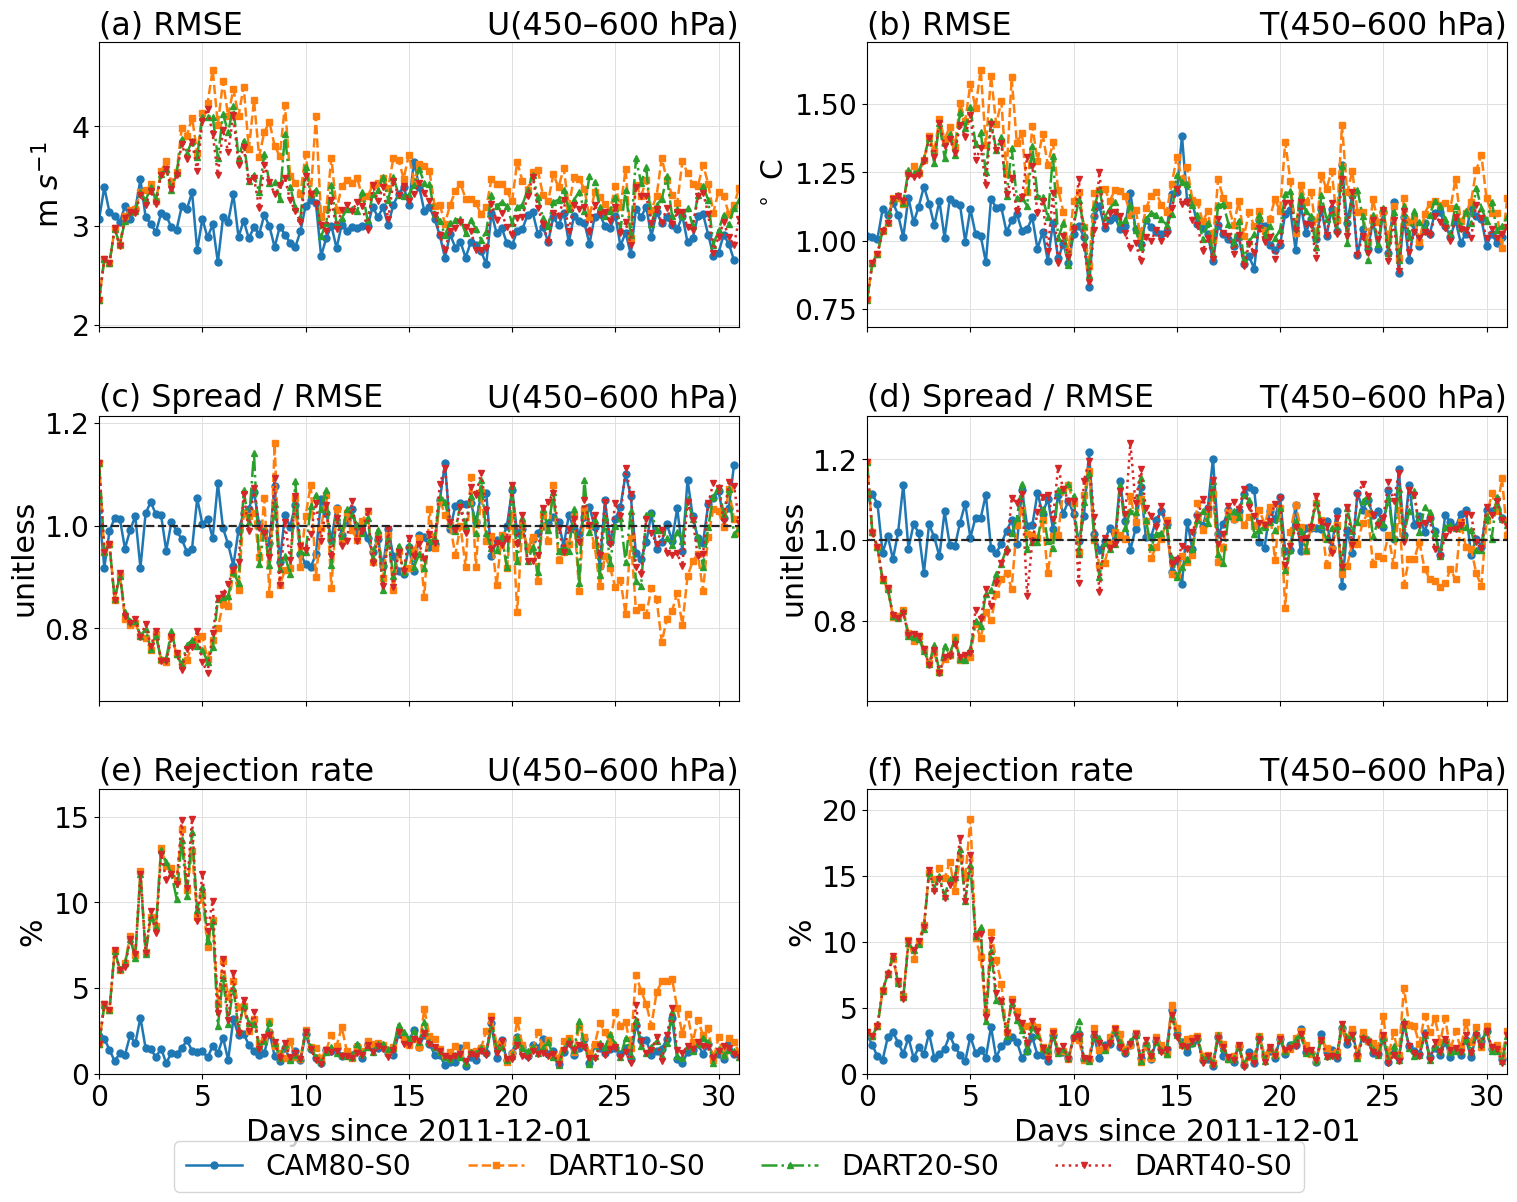

In [128]:
figure_result = plot_processed_diagnostics(
    processed_diagnostics,
    mode=PLOT_MODE,
    focused_common_s0=FOCUSED_COMMON_S0,
    focused_plot_config=COMMON_S0_FIGURE,
)


### All-layer global summary

The summary cell computes time-mean RMSE, spread/RMSE, and pooled rejection for each experiment and pressure bin, then reports equal-weight averages across the 14 bins and the number of bins won on RMSE. It writes `obs_diag_Global_all-layers_summary.csv` under the workflow data directory. Rejection rate is descriptive, not a direct measure of skill. S0 and S1 cover different months, so compare each season’s experiments internally rather than interpreting their difference as a controlled seasonal effect.

In [129]:
all_layer_datasets = {
    "S0": read_or_process_diagnostics(
        mode="obs_space",
        use_dask=USE_DASK,
        dask_chunks=DASK_CHUNKS,
        persist_means=PERSIST_MEANS,
        force_compute=FORCE_COMPUTE,
    ),
    "S1": read_or_process_diagnostics(
        mode="obs_space_s1",
        use_dask=USE_DASK,
        dask_chunks=DASK_CHUNKS,
        persist_means=PERSIST_MEANS,
        force_compute=FORCE_COMPUTE,
    ),
}

all_layer_rows = []
layer_metric_rows = []
for season, processed in all_layer_datasets.items():
    for variable in OBS_SPACE_FIGURE["variables"]:
        entry = processed[variable]
        levels = list(entry["levels"])
        for experiment, data in entry["data"].items():
            time = np.asarray(data["time"], dtype=float)
            time_mask = (time >= XMIN) & (time <= XMAX)
            layer_means = {}
            for metric in ("rmse", "spread", "rejection"):
                values = np.asarray(_metric_values(data, metric), dtype=float)
                if values.shape[0] != time.size:
                    values = values.T
                means_by_layer = np.nanmean(values[time_mask], axis=0)
                layer_means[metric] = means_by_layer
                for index, level in enumerate(levels):
                    layer_metric_rows.append({
                        "season": season,
                        "variable": variable,
                        "level": level,
                        "experiment": experiment,
                        "metric": metric,
                        "time_mean": means_by_layer[index],
                    })

            all_layer_rows.append({
                "season": season,
                "variable": variable,
                "experiment": experiment,
                "pressure_bins": len(levels),
                "mean_RMSE": np.nanmean(layer_means["rmse"]),
                "mean_spread_RMSE": np.nanmean(layer_means["spread"]),
                "mean_rejection_pct": np.nanmean(layer_means["rejection"]),
                "spread_RMSE_mean_abs_error_from_1": np.nanmean(
                    np.abs(layer_means["spread"] - 1.0)
                ),
            })

all_layer_summary = pd.DataFrame(all_layer_rows).round(3)
layer_metrics = pd.DataFrame(layer_metric_rows)
print("All-layer global means; each pressure bin is weighted equally:")
print(all_layer_summary.to_string(index=False))

for season in all_layer_datasets:
    for variable in OBS_SPACE_FIGURE["variables"]:
        subset = layer_metrics[
            (layer_metrics["season"] == season)
            & (layer_metrics["variable"] == variable)
        ]
        rmse_rows = subset[subset["metric"] == "rmse"]
        spread_rows = subset[subset["metric"] == "spread"].copy()
        spread_rows["distance_from_one"] = np.abs(spread_rows["time_mean"] - 1.0)
        rmse_wins = {}
        spread_closest = {}
        for level in rmse_rows["level"].unique():
            level_rmse = rmse_rows[rmse_rows["level"] == level]
            best = level_rmse["time_mean"].min()
            for experiment in level_rmse.loc[
                np.isclose(level_rmse["time_mean"], best), "experiment"
            ]:
                rmse_wins[experiment] = rmse_wins.get(experiment, 0) + 1

            level_spread = spread_rows[spread_rows["level"] == level]
            closest = level_spread["distance_from_one"].min()
            for experiment in level_spread.loc[
                np.isclose(level_spread["distance_from_one"], closest), "experiment"
            ]:
                spread_closest[experiment] = spread_closest.get(experiment, 0) + 1
        print(
            f"{season} {variable}: lowest RMSE by bin={rmse_wins}; "
            f"spread/RMSE closest to 1 by bin={spread_closest}"
        )

summary_dir = WORKFLOW_DATA_DIR / "obs_diagnostics" / "time_series"
summary_dir.mkdir(parents=True, exist_ok=True)
summary_path = summary_dir / (
    f"obs_diag_{_cache_token(REGION_NAMES.get(REGION, REGION))}_all-layers_summary.csv"
)
all_layer_summary.to_csv(summary_path, index=False)
print(f"Saved all-layer summary: {summary_path}")

[REUSE] /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/data/analysis_atm_da/obs_diagnostics/time_series/obs_diag_obs-space_Global_U-WIND.nc
[REUSE] /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/data/analysis_atm_da/obs_diagnostics/time_series/obs_diag_obs-space_Global_Temperature.nc
[REUSE] /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/data/analysis_atm_da/obs_diagnostics/time_series/obs_diag_obs-space-s1_Global_U-WIND.nc
[REUSE] /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/data/analysis_atm_da/obs_diagnostics/time_series/obs_diag_obs-space-s1_Global_Temperature.nc
All-layer global means; each pressure bin is weighted equally:
season    variable experiment  pressure_bins  mean_RMSE  mean_spread_RMSE  mean_rejection_pct  spread_RMSE_mean_abs_error_from_1
    S0      U_WIND   CAM80-S0             14      3.381             0.971              34.792                              0.042
    S0      U_WIND  DART10-S0             14      3.964             0.894              25.474              

In [130]:
obs_space_s1_label_refresh = plot_obs_space_summary(
    all_layer_datasets["S1"], "obs_space_s1", show=False, save=True
)
assert all_layer_datasets["S1"]["Temperature"]["name"] == "T"

Saved all-layer obs-space report: /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/figure/analysis_atm_da/obs_diagnostics/time_series/fig_obs_diag_obs-space-s1_U_T_Global_all-layers.pdf
Saved example obs-space figure: /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/figure/analysis_atm_da/obs_diagnostics/time_series/fig_obs_diag_obs-space-s1_U_T_Global_example.pdf
